# Visualizer
In this project step, the prepared data are inspected. 



In [111]:
## IMPORT LIBRARIES
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from datetime import datetime
from dataclasses import dataclass
from sklearn. model_selection import train_test_split
from sklearn. preprocessing import MinMaxScaler

In [112]:
# CREATE LOGGER FOR JUPYTER NOTEBOOKS
def setup_logger():
    # Create logger instance
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    # Clear existing, avoid duplicate logs
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create FileHandler in overrite mode
    file_handler = logging.FileHandler('lognotebooks.log', mode ='w')

    # Set format
    formatter = logging.Formatter('%(asctime)s - %(levelno)s - %(lineno)d - %(module)s - %(message)s')
    file_handler.setFormatter(formatter)

    # Add FileHandler to logger
    logger.addHandler(file_handler)

    return logger

In [113]:
## INSPECT THE RAW DATA
logger = setup_logger()
def inspect_raw_data(df, output_path=None):
    '''
    Inspect a DataFrame and save info to a text file.
    Parameters:
    df : pandas DataFrame
    output_path : Path or str, optional
        Where to save the output file. If None and save_to_file is True,
        will use current directory
    '''

    # Set display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Prepare the information
    info_text = []
    info_text.append(f"Generated on: {datetime.now()}")
    info_text.append(f"Shape: {df.shape}")
    
    # Get info in string format
    buffer = StringIO()
    df.info(buf=buffer)
    info_text.append(f"\nDataFrame Info:")
    info_text.append(buffer.getvalue())

    # Add first 5 rows
    buffer_head = StringIO()
    df.head().to_string(buf=buffer_head)
    info_text.append(f"\nFirst 5 rows:")
    info_text.append(buffer_head.getvalue())

    # Add last 5 rows
    buffer_tail = StringIO()
    df.tail().to_string(buf=buffer_tail)
    info_text.append(f"\nLast 5 rows:")
    info_text.append(buffer_tail.getvalue())
    
    # Join all information
    full_report = '\n'.join(info_text)
    output_path = Path(output_path)
    output_path.write_text(full_report)
    logger.info(f"Report saved to: {output_path}")
    
    return full_report

# Define data path
data_path = Path('..') / '..' / 'data' / 'processed' / 'DataPrep' 
for file in data_path.glob('*.csv'):
    logger.info(f'Available csv file: {file.name}')

# Read in data
df_eso = pd.read_csv(data_path / 'merged_eso_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']
df_smard = pd.read_csv(data_path / 'merged_smard_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']

eso = 'eso'; smard = 'smard'
inspect_raw_data(df_eso, output_path=Path(f'{data_path}/../Visualizer/{eso}_inspection.txt'))
inspect_raw_data(df_smard, output_path=Path(f'{data_path}/../Visualizer/{smard}_inspection.txt'))

"Generated on: 2024-11-19 20:24:12.405443\nShape: (129767, 66)\n\nDataFrame Info:\n<class 'pandas.core.frame.DataFrame'>\nRangeIndex: 129767 entries, 0 to 129766\nData columns (total 66 columns):\n #   Column                                                    Non-Null Count   Dtype         \n---  ------                                                    --------------   -----         \n 0   ID                                                        129767 non-null  datetime64[ns]\n 1   Stromfluss_Nettoexport [MWh]                              129767 non-null  float64       \n 2   Stromfluss_Niederlande (Export) [MWh]                     129767 non-null  float64       \n 3   Stromfluss_Niederlande (Import) [MWh]                     129767 non-null  float64       \n 4   Stromfluss_Schweiz (Export) [MWh]                         129767 non-null  float64       \n 5   Stromfluss_Schweiz (Import) [MWh]                         129767 non-null  float64       \n 6   Stromfluss_Dänemark (Export) [

# Compare the features of the data
Check eso_inspection.txt and smard_inspection.txt in the 'processed' directory.
The table shows the features that are manually assignable at the first check.

                                               
| UK         | German (DE)                                                      |
|------------|------------------------------------------------------------------|
| Power Generation by Source:                                                   |
| GAS        | Erzeugung_Erdgas [MWh]                                           |
| COAL       | Erzeugung_Steinkohle [MWh] + Erzeugung_Braunkohle [MWh]          |
| NUCLEAR    | Erzeugung_Kernenergie [MWh]                                      |
| WIND       | Erzeugung_Wind Offshore [MWh] + Erzeugung_Wind Onshore [MWh]     |
| HYDRO      | Erzeugung_Wasserkraft [MWh]                                      |
| BIOMASS    | Erzeugung_Biomasse [MWh]                                         |
| SOLAR      | Erzeugung_Photovoltaik [MWh]                                     |
| STORAGE    | Erzeugung_Pumpspeicher [MWh]                                     |
| Demand/Load:                                                                  |
| ENGLAND_WALES_DEMAND  | Stromverbrauch_Gesamt (Netzlast) [MWh]                |
| PUMP_STORAGE_PUMPING  | Stromverbrauch_Pumpspeicher [MWh]                     |
| Cross-border flows (various interconnector flows):                            |          
| IFA_FLOW              | Stromfluss_Niederlande (Export/Import)                |
| BRITNED_FLOW          | Stromfluss_Frankreich (Export/Import)                 |
| MOYLE_FLOW            | Stromfluss_Polen (Export/Import)                      |
| etc.                  | etc.                                                  |
| System Balancing:                                                             |
| Energy Imbalance          |  Ausgleichsenergie_Volumen (+/-) [MWh]            |
| Frequency Control         |  Sekund_Abgerufene Menge (+/-) [MWh]              |
| Positive/Negative Reserve |   Minutenreserve_Abgerufene Menge (+/-) [MWh]     |


In [114]:
## SPLITTING DATA
# ESO
eso_target_cols = ['GAS', 'COAL', 'NUCLEAR']
X_eso_dd = df_eso.loc[:, ~df_eso.columns.isin(eso_target_cols)]
y_eso_dd = df_eso.loc[:, eso_target_cols]

X_train_eso, X_test_eso, y_train_eso, y_test_eso = train_test_split(X_eso_dd, y_eso_dd, test_size=0.25, random_state=42)

# SMARD
smard_target_cols = ['Erzeugung_Erdgas [MWh]', 'Erzeugung_Steinkohle [MWh]', 
                     'Erzeugung_Braunkohle [MWh]', 'Erzeugung_Kernenergie [MWh]']

X_smard_dd = df_smard.loc[:, ~df_smard.columns.isin(smard_target_cols)]
y_smard_dd = df_smard.loc[:, smard_target_cols]

X_train_smard, X_test_smard, y_train_smard, y_test_smard = train_test_split(X_smard_dd, y_smard_dd, 
                                                                            test_size=0.25, random_state=42)

In [115]:
# ESO dataset
# Remove datetime index from scaling but keep it for later
datetime_index_eso = X_train_eso.index
X_train_eso_no_time = X_train_eso.select_dtypes(include=['float64', 'int64'])
X_test_eso_no_time = X_test_eso.select_dtypes(include=['float64', 'int64'])

# Initialize and fit scalers
X_scaler_eso = MinMaxScaler()
y_scaler_eso = MinMaxScaler()

# Scale the data
X_train_eso_scaled = X_scaler_eso.fit_transform(X_train_eso_no_time)
y_train_eso_scaled = y_scaler_eso.fit_transform(y_train_eso)
X_test_eso_scaled = X_scaler_eso.transform(X_test_eso_no_time)
y_test_eso_scaled = y_scaler_eso.transform(y_test_eso)

# SMARD dataset
# Remove datetime index from scaling but keep it for later
datetime_index_smard = X_train_smard.index
X_train_smard_no_time = X_train_smard.select_dtypes(include=['float64', 'int64'])
X_test_smard_no_time = X_test_smard.select_dtypes(include=['float64', 'int64'])

# Initialize and fit scalers
X_scaler_smard = MinMaxScaler()
y_scaler_smard = MinMaxScaler()

# Scale the data
X_train_smard_scaled = X_scaler_smard.fit_transform(X_train_smard_no_time)
y_train_smard_scaled = y_scaler_smard.fit_transform(y_train_smard)
X_test_smard_scaled = X_scaler_smard.transform(X_test_smard_no_time)
y_test_smard_scaled = y_scaler_smard.transform(y_test_smard)

# Convert back to DataFrames with the original datetime index
X_train_eso_scaled = pd.DataFrame(X_train_eso_scaled, 
                                 columns=X_train_eso_no_time.columns,
                                 index=datetime_index_eso)
X_test_eso_scaled = pd.DataFrame(X_test_eso_scaled, 
                                columns=X_test_eso_no_time.columns,
                                index=X_test_eso.index)
y_train_eso_scaled = pd.DataFrame(y_train_eso_scaled, 
                                 columns=y_train_eso.columns,
                                 index=datetime_index_eso)
y_test_eso_scaled = pd.DataFrame(y_test_eso_scaled, 
                                columns=y_test_eso.columns,
                                index=X_test_eso.index)

X_train_smard_scaled = pd.DataFrame(X_train_smard_scaled, 
                                   columns=X_train_smard_no_time.columns,
                                   index=datetime_index_smard)
X_test_smard_scaled = pd.DataFrame(X_test_smard_scaled, 
                                  columns=X_test_smard_no_time.columns,
                                  index=X_test_smard.index)
y_train_smard_scaled = pd.DataFrame(y_train_smard_scaled, 
                                   columns=y_train_smard.columns,
                                   index=datetime_index_smard)
y_test_smard_scaled = pd.DataFrame(y_test_smard_scaled, 
                                  columns=y_test_smard.columns,
                                  index=X_test_smard.index)

# Verify the scaling worked
print("\nVerifying ESO scaling:")
print("X_train_eso_scaled shape:", X_train_eso_scaled.shape)
print("X_test_eso_scaled shape:", X_test_eso_scaled.shape)
print("\nVerifying SMARD scaling:")
print("X_train_smard_scaled shape:", X_train_smard_scaled.shape)
print("X_test_smard_scaled shape:", X_test_smard_scaled.shape)



Verifying ESO scaling:
X_train_eso_scaled shape: (97325, 82)
X_test_eso_scaled shape: (32442, 82)

Verifying SMARD scaling:
X_train_smard_scaled shape: (97325, 61)
X_test_smard_scaled shape: (32442, 61)


/tmp/ipykernel_10565/3018327569.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i, 1].legend()


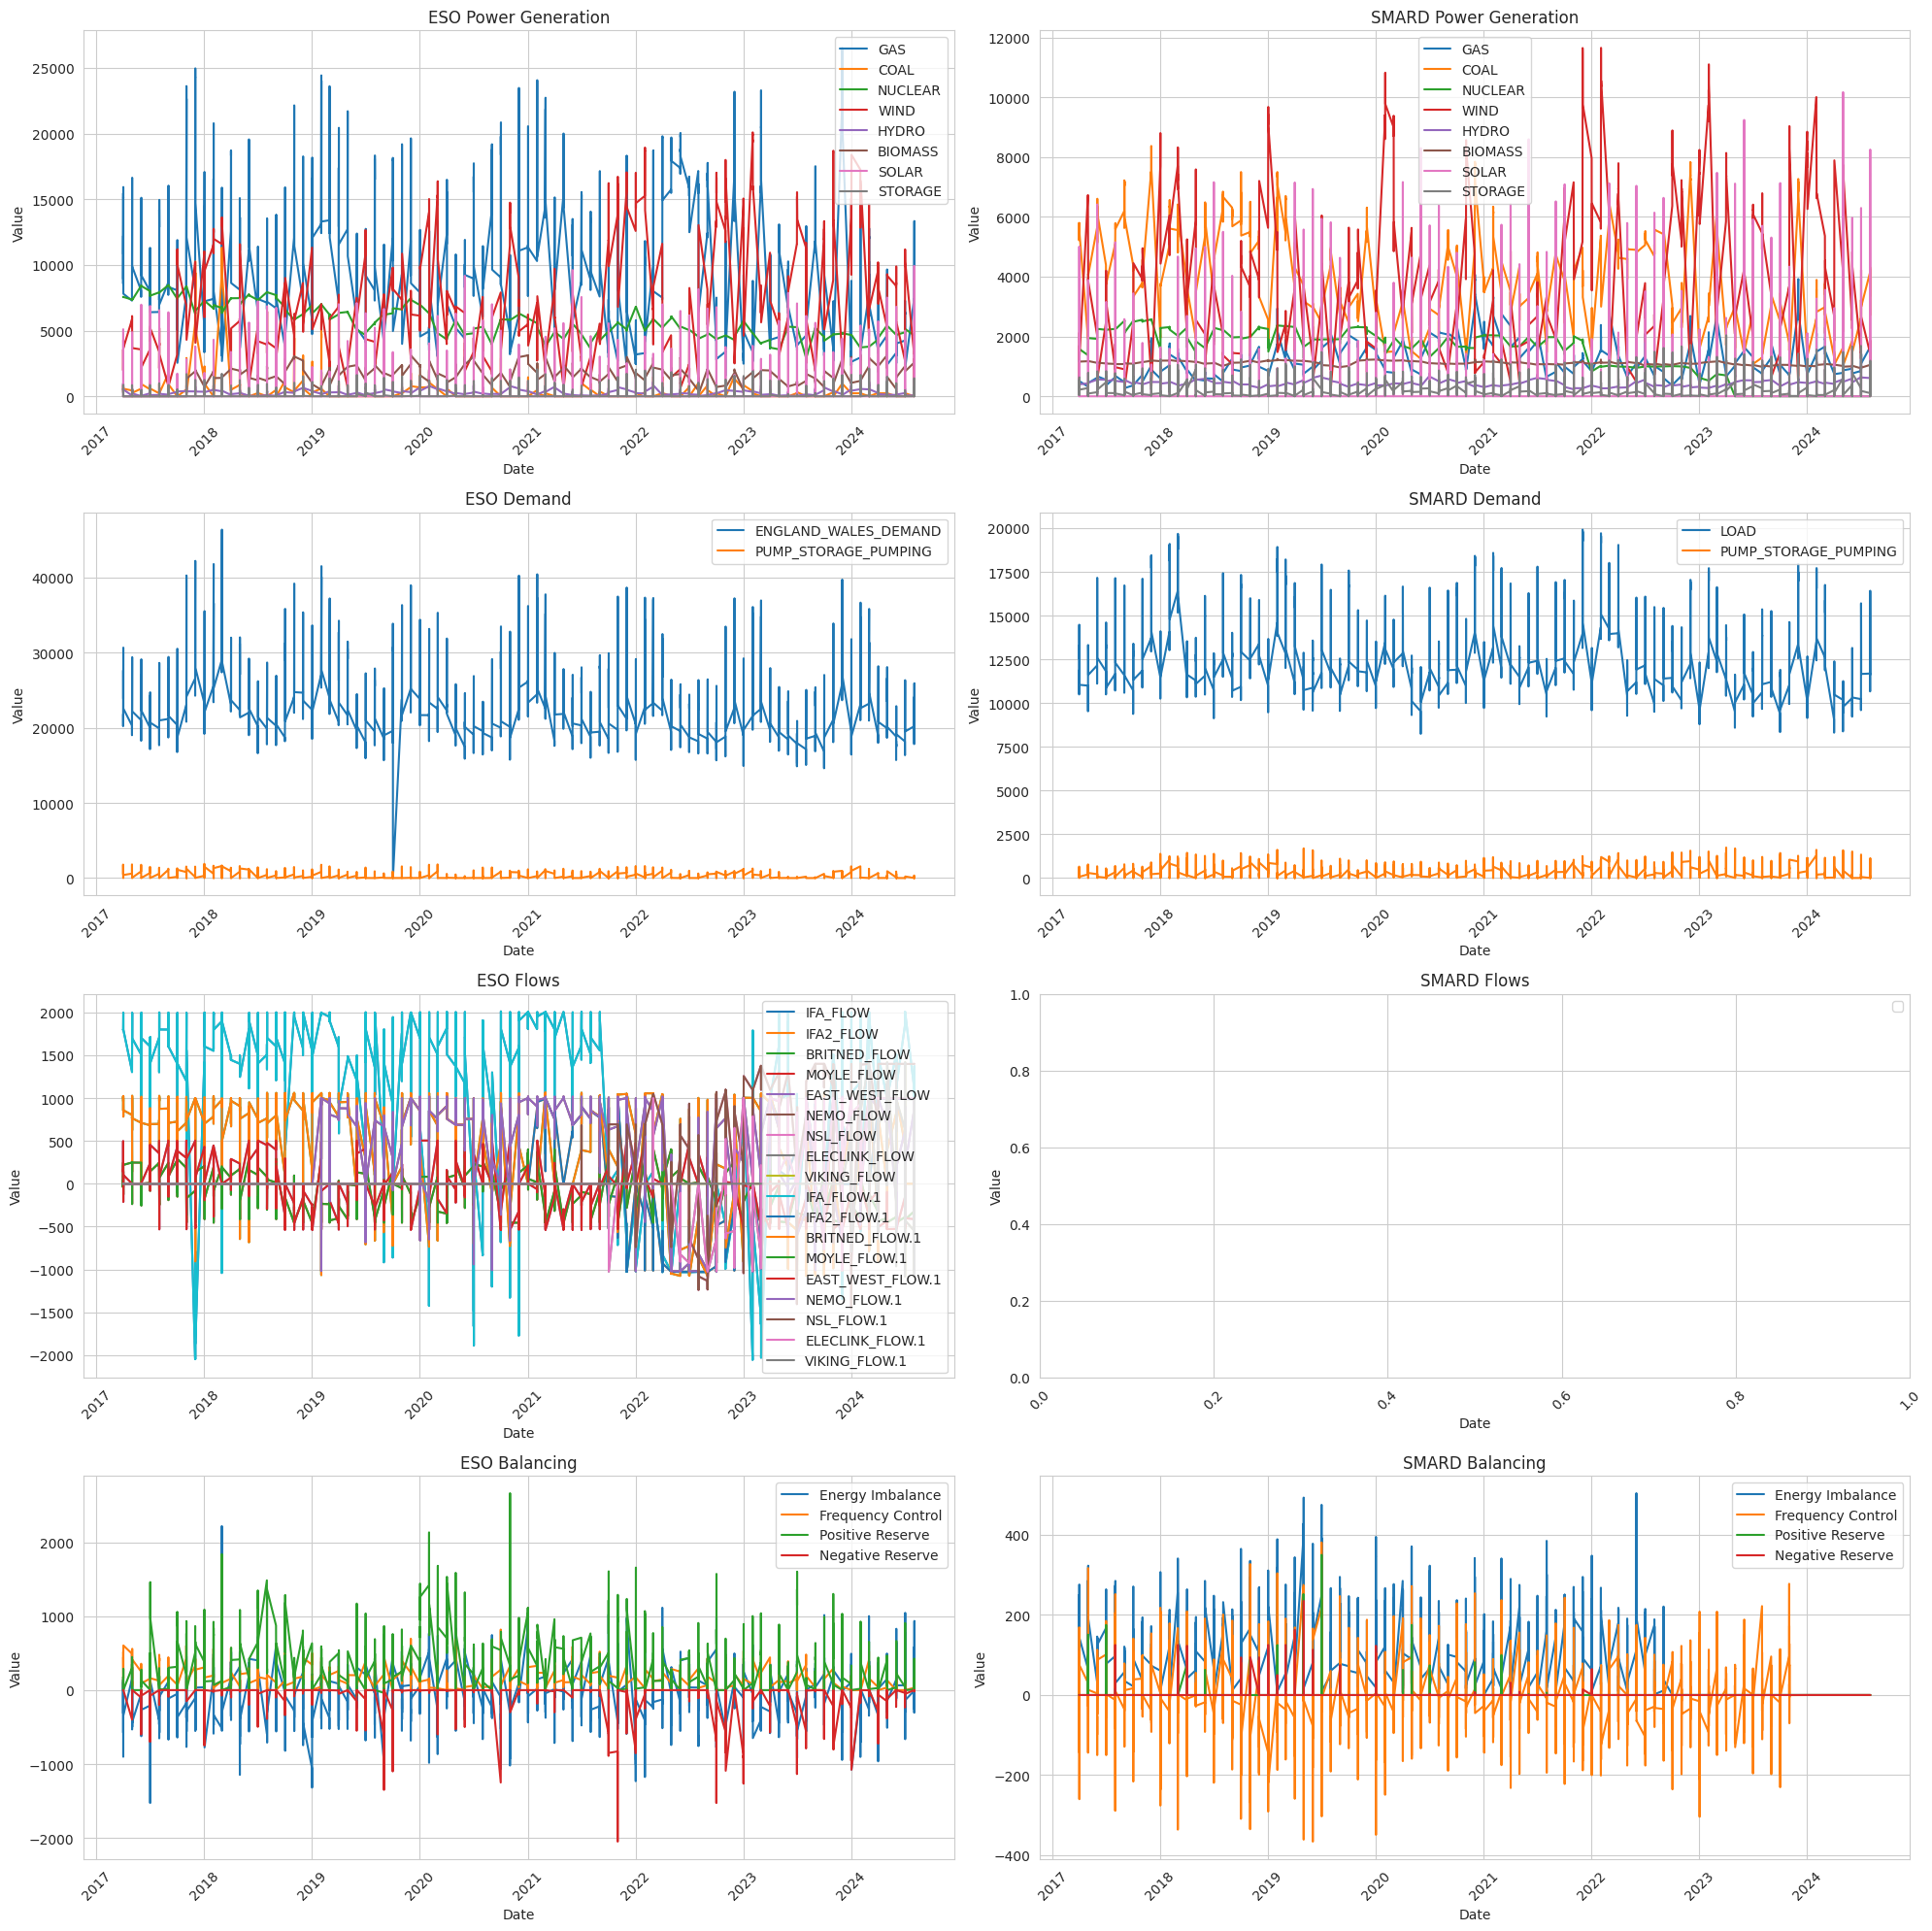


ESO Data Info:
Total rows in ESO: 129767
Monthly rows in ESO: 4271

SMARD Data Info:
Total rows in SMARD: 129767
Monthly rows in SMARD: 4271


In [116]:
@dataclass
class Visualizer:
    df_eso: pd.DataFrame
    df_smard: pd.DataFrame

    def __post_init__(self):
        self.eso_power_gen = {
            'GAS': self.df_eso['GAS'],
            'COAL': self.df_eso['COAL'],
            'NUCLEAR': self.df_eso['NUCLEAR'],
            'WIND': self.df_eso['WIND'],
            'HYDRO': self.df_eso['HYDRO'],
            'BIOMASS': self.df_eso['BIOMASS'],
            'SOLAR': self.df_eso['SOLAR'],
            'STORAGE': self.df_eso['STORAGE']
        }

        self.eso_demand = {
            'ENGLAND_WALES_DEMAND': self.df_eso['ENGLAND_WALES_DEMAND'],
            'PUMP_STORAGE_PUMPING': self.df_eso['PUMP_STORAGE_PUMPING']
        }

        self.eso_flows = {
            col: self.df_eso[col] for col in self.df_eso.columns if 'FLOW' in col
        }

        self.eso_balancing = {
            'Energy Imbalance': self.df_eso['Energy Imbalance (MWh)'],
            'Frequency Control': self.df_eso['Frequency Control Offers (MWh)'] - self.df_eso['Frequency Control Bids (MWh)'],
            'Positive Reserve': self.df_eso['Positive Reserve (MWh)'],
            'Negative Reserve': self.df_eso['Negative Reserve (MWh)']
        }

        self.smard_power_gen = {
            'GAS': self.df_smard['Erzeugung_Erdgas [MWh]'], 
            'COAL': self.df_smard['Erzeugung_Steinkohle [MWh]'] + self.df_smard['Erzeugung_Braunkohle [MWh]'],
            'NUCLEAR': self.df_smard['Erzeugung_Kernenergie [MWh]'],
            'WIND': self.df_smard['Erzeugung_Wind Offshore [MWh]'] + self.df_smard['Erzeugung_Wind Onshore [MWh]'], 
            'HYDRO': self.df_smard['Erzeugung_Wasserkraft [MWh]'],
            'BIOMASS': self.df_smard['Erzeugung_Biomasse [MWh]'],
            'SOLAR': self.df_smard['Erzeugung_Photovoltaik [MWh]'],
            'STORAGE': self.df_smard['Erzeugung_Pumpspeicher [MWh]']
        }

        self.smard_demand = {
            'LOAD': self.df_smard['Stromverbrauch_Gesamt (Netzlast) [MWh]'],
            'PUMP_STORAGE_PUMPING': self.df_smard['Stromverbrauch_Pumpspeicher [MWh]'] 
        }

        self.smard_flows = {
            col: self.df_eso[col] for col in self.df_eso.columns if 'Stromfluss' in col
        }

        self.smard_balancing = {
            'Energy Imbalance': self.df_smard['Ausgleichsenergie_Volumen (+) [MWh]'] - self.df_smard['Ausgleichsenergie_Volumen (-) [MWh]'],
            'Frequency Control': self.df_smard['Sekund_Abgerufene Menge (+) [MWh]'] - self.df_smard['Sekund_Abgerufene Menge (-) [MWh]'], 
            'Positive Reserve': self.df_smard['Minutenreserve_Abgerufene Menge (+) [MWh]'],
            'Negative Reserve': self.df_smard['Minutenreserve_Abgerufene Menge (-) [MWh]']
        }

    def create_plots(self):
        fig, axs = plt.subplots(4, 2, figsize=(20, 20))

        # ESO plots
        for i, (title, data_dict) in enumerate([
            ('ESO Power Generation', self.eso_power_gen),
            ('ESO Demand', self.eso_demand),  
            ('ESO Flows', self.eso_flows),
            ('ESO Balancing', self.eso_balancing)
        ]):
            axs[i, 0].set_title(title)
            # Get monthly data
            monthly_mask = self.df_eso['ID'].dt.day == 1
            monthly_dates = self.df_eso.loc[monthly_mask, 'ID']
            
            for col, series in data_dict.items():
                try:
                    # Get monthly values for this series
                    monthly_values = series[monthly_mask]
                    axs[i, 0].plot(monthly_dates, monthly_values, label=col)
                except Exception as e:
                    print(f"Error plotting {col} in ESO data for {title}: {str(e)}")
                    continue
            axs[i, 0].legend()
            axs[i, 0].set_xlabel('Date')
            axs[i, 0].set_ylabel('Value')

        # SMARD plots  
        for i, (title, data_dict) in enumerate([
            ('SMARD Power Generation', self.smard_power_gen),
            ('SMARD Demand', self.smard_demand),
            ('SMARD Flows', self.smard_flows),
            ('SMARD Balancing', self.smard_balancing)
        ]):
            axs[i, 1].set_title(title)
            # Get monthly data
            monthly_mask = self.df_smard['ID'].dt.day == 1
            monthly_dates = self.df_smard.loc[monthly_mask, 'ID']
            
            for col, series in data_dict.items():
                try:
                    # Get monthly values for this series
                    monthly_values = series[monthly_mask]
                    axs[i, 1].plot(monthly_dates, monthly_values, label=col)
                except Exception as e:
                    print(f"Error plotting {col} in SMARD data for {title}: {str(e)}")
                    continue
            axs[i, 1].legend()
            axs[i, 1].set_xlabel('Date')  
            axs[i, 1].set_ylabel('Value')

        # Rotate x-axis labels for better readability
        for ax in axs.flat:
            ax.tick_params(axis='x', rotation=45)

        fig.tight_layout()
        plt.show()

        # Print some debugging information
        print("\nESO Data Info:")
        print(f"Total rows in ESO: {len(self.df_eso)}")
        print(f"Monthly rows in ESO: {sum(self.df_eso['ID'].dt.day == 1)}")
        
        print("\nSMARD Data Info:")
        print(f"Total rows in SMARD: {len(self.df_smard)}")
        print(f"Monthly rows in SMARD: {sum(self.df_smard['ID'].dt.day == 1)}")
visualizer = Visualizer(df_eso, df_smard)
visualizer.create_plots()

In [117]:
'''import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_feature_categories(df, figsize=(20, 12)):
    """
    Plot different categories of features over time
    """
    # Define feature categories
    categories = {
        'Generation Mix': ['GAS_perc', 'NUCLEAR_perc', 'WIND_perc', 'SOLAR_perc', 
                         'HYDRO_perc', 'BIOMASS_perc'],
        'Carbon Metrics': ['CARBON_INTENSITY', 'LOW_CARBON_perc', 'ZERO_CARBON_perc', 
                          'RENEWABLE_perc', 'FOSSIL_perc'],
        'System Metrics': ['Outturn Inertia', 'Market Provided Inertia', 'GENERATION']
    }
    
    # Create subplots for each category
    fig, axes = plt.subplots(len(categories), 1, figsize=figsize)
    fig.suptitle('Energy Features Over Time', fontsize=16)
    
    for idx, (category, features) in enumerate(categories.items()):
        for feature in features:
            axes[idx].plot(df.index, df[feature], label=feature, alpha=0.7)
        axes[idx].set_title(category)
        axes[idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[idx].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, features_to_analyze, figsize=(12, 10)):
    """
    Plot correlation heatmap for selected features
    """
    plt.figure(figsize=figsize)
    correlation_matrix = df[features_to_analyze].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

def plot_pca_analysis(df, features_to_analyze, n_components=2):
    """
    Perform and plot PCA analysis
    """
    # Standardize the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df[features_to_analyze])
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(scaled_data)
    
    # Plot explained variance ratio
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_components + 1), 
            np.cumsum(pca.explained_variance_ratio_), 
            'bo-')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.title('PCA Explained Variance Ratio')
    plt.grid(True)
    plt.show()
    
    return pca_result, pca.explained_variance_ratio_

def plot_feature_distributions(df, features, figsize=(15, 10)):
    """
    Plot distribution of selected features
    """
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.ravel()
    
    for idx, feature in enumerate(features):
        sns.histplot(data=df, x=feature, ax=axes[idx], kde=True)
        axes[idx].set_title(f'{feature} Distribution')
    
    # Remove empty subplots
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

# Example usage:
def visualize_energy_data(df):
    """
    Main function to create all visualizations
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_vis = df.copy()
    
    # Set ID as index if it's not already
    if 'ID' in df_vis.columns:
        df_vis.set_index('ID', inplace=True)
    
    # 1. Plot time series for different categories
    plot_feature_categories(df_vis)
    
    # 2. Select important features for correlation analysis
    important_features = [
        'GAS_perc', 'NUCLEAR_perc', 'WIND_perc', 'SOLAR_perc',
        'CARBON_INTENSITY', 'RENEWABLE_perc', 'FOSSIL_perc',
        'Outturn Inertia', 'Market Provided Inertia'
    ]
    plot_correlation_heatmap(df_vis, important_features)
    
    # 3. PCA Analysis
    pca_result, explained_variance = plot_pca_analysis(df_vis, important_features, n_components=5)
    
    # 4. Distribution plots
    key_features = ['CARBON_INTENSITY', 'RENEWABLE_perc', 'FOSSIL_perc', 
                   'GAS_perc', 'WIND_perc', 'NUCLEAR_perc']
    plot_feature_distributions(df_vis, key_features)

# Usage example:
# visualize_energy_data(df)

visualize_energy_data(df_eso)'''

'import numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\n\ndef plot_feature_categories(df, figsize=(20, 12)):\n    """\n    Plot different categories of features over time\n    """\n    # Define feature categories\n    categories = {\n        \'Generation Mix\': [\'GAS_perc\', \'NUCLEAR_perc\', \'WIND_perc\', \'SOLAR_perc\', \n                         \'HYDRO_perc\', \'BIOMASS_perc\'],\n        \'Carbon Metrics\': [\'CARBON_INTENSITY\', \'LOW_CARBON_perc\', \'ZERO_CARBON_perc\', \n                          \'RENEWABLE_perc\', \'FOSSIL_perc\'],\n        \'System Metrics\': [\'Outturn Inertia\', \'Market Provided Inertia\', \'GENERATION\']\n    }\n    \n    # Create subplots for each category\n    fig, axes = plt.subplots(len(categories), 1, figsize=figsize)\n    fig.suptitle(\'Energy Features Over Time\', fontsize=16)\n    \n    for idx, (category, features) in enumerate(categori